# Práctica computacional 2: Predicción de estructuras proteicas y alineamientos estructurales

<a href="https://colab.research.google.com/github/Nieto-CaballeroVE/CdeCMx2025_GTO4/blob/master/notebooks/ComputerLab1_AlphaFold_Foldseek.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

La mayoría de los organismos que habitan nuestro planeta poseen relojes circadianos endógenos. La luz sirve como la señal ambiental principal para sincronizar los ritmos. <br> <br>

Cómo los animales son capaces de percibir la luz y traducirla a señales bioquímicas representa un proceso complejo y fascinante. Como hemos aprendido, mucho se debe a la interacción y expresión regulada de ciertos genes y sus productos proteicos. <br> <br>

La función de las proteínas está directamente ligada a su estructura, y modificaciones en ellas han permitido la adaptación a distintos entornos. <br> <br>

En esta práctica, seguiremos usando el genoma de una araña tejedora (*Hylyphantes graminicola*); generaremos predicciones de la estructura de algunas proteínas implicadas en el ciclo circadiano y las compararemos con otras especies.

<img src="https://raw.githubusercontent.com/sokrypton/ColabFold/main/.github/ColabFold_Marv_Logo_Small.png" height="200" align="right" style="height:240px">

## Acerca del método

Usaremos **ColabFold**, una implementación que acelera la predicción combinando la búsqueda rápida de homología de **MMseqs2** con **AlphaFold2**. Si quieres saber más, puedes consultar la publicación en:

[Mirdita M, Schütze K, Moriwaki Y, Heo L, Ovchinnikov S, Steinegger M. ColabFold: Making protein folding accessible to all.
*Nature Methods*, 2022](https://www.nature.com/articles/s41592-022-01488-1)

# Instrucciones generales

Para obtener instrucciones detalladas, consejos y trucos, puedes consultar el artículo publicado en [Nature Protocols](https://www.nature.com/articles/s41596-024-01060-5).

**Inicio rapido**
1. Pega tu secuencia proteica en el campo de entrada.
2. Puedes correr cada celda individulamente o haer clic en "Runtime" -> "Run all".
3. El pipeline consta de 5 pasos. El paso que está en ejecución se indica con un círculo que lleva un símbolo de alto al lado.<br>

Al finalizar el trabajo aparecerá una ventana emergente para descargar el archivo `jobname.result.zip` . Además, si se seleccionó la opción `save_to_google_drive`, dicho archivo se subirá automáticamente a tu Google Drive.<br><br>

**Solución de problemas**
* Verifique que el tipo de entorno de ejecución esté configurado en GPU en "Runtime" → "Change runtime type".
* Intente reiniciar la sesión: "Runtime" → "Factory reset runtime".
* Revise su secuencia de entrada. <br><br>

**Problemas conocidos**
* Google Colab asigna distintos tipos de GPU con cantidades variables de memoria. Algunas podrían no tener memoria suficiente para predecir la estructura de una secuencia larga.
* El navegador puede bloquear la ventana emergente para descargar el archivo de resultados. Puedes elegir la opción `save_to_google_drive` para subir el archivo a Google Drive o descargar el archivo manualmente: haga clic en el ícono de la carpeta a la izquierda, navegue hasta `jobname.result.zip`, haz clic derecho y selecciona 'Download".

**Limitaciones**
* Recursos de cómputo: La API de MMseqs2 puede gestionar ~20-50 k solicitudes por día. <br><br>

## Conociendo los datos

La siguiente secuencia de aminoacidos corresponde al gen *evm.model.CTG_1086.63* el cual basado en similitud a nivel de secuencia de ADN parece ser homologo a opsinas, un grupo de proteinas fotosensibles.

![](https://github.com/Nieto-CaballeroVE/CdeCMx2025_GTO4/blob/main/media/retinallocation1.jpg?raw=true)



In [4]:
#@title Introduce secuencia de interés en el campo "query_sequence"
#@markdown - El notebook se encargara del resto, no es necesario modificar por ahora ninguna otra opcion.
from google.colab import files
import os
import re
import hashlib
import random

from sys import version_info
python_version = f"{version_info.major}.{version_info.minor}"

def add_hash(x,y):
  return x+"_"+hashlib.sha1(y.encode()).hexdigest()[:5]

query_sequence = 'MSSQVMMNSAFMANRGMIGAAPAGLGVAPATYDGAFFPYQRNATVVDNVPHEILHMIHEHWYQFPPMNPLWHSLLGMAMIVLGIVSVIGNGMVVYLMSTTKSLKTPTNMLIVNLAFSDFCMMAFMMPTMAANCFAETWILGPFMCEVYGMAGSLFGCVSIWSMVMIAFDRYNVIVKGMSGEPLTSKKAAVQILLVWAWSAVWTLAPFFGWNKYVPEGNMTSCTIDYLTKEWNSSSYVVLYGIAVYFVPLFTLIYNYTFIVRSVADHEKQLREQAKKMNVSSLRANSDQQKQSAECRLAKIAMMTVGLWFIAWTPYLSIAWSGVFSTGKRLTPLATIWGAVFAKAVAVYNPIVYGISHPKYRAALLQKFPSLACATEGHGDHGADTRSDTTVVSDEKPPKGSEA' #@param {type:"string"}
jobname = 'test_opsin' #@param {type:"string"}
# number of models to use
num_relax = 0 #@param [0, 1, 5] {type:"raw"}
#@markdown - specify how many of the top ranked structures to relax using amber
template_mode = "none" #@param ["none", "pdb100","custom"]
#@markdown - `none` = no template information is used. `pdb100` = detect templates in pdb100 (see [notes](#pdb100)). `custom` - upload and search own templates (PDB or mmCIF format, see [notes](#custom_templates))

use_amber = num_relax > 0

# remove whitespaces
query_sequence = "".join(query_sequence.split())

basejobname = "".join(jobname.split())
basejobname = re.sub(r'\W+', '', basejobname)
jobname = add_hash(basejobname, query_sequence)

# check if directory with jobname exists
def check(folder):
  if os.path.exists(folder):
    return False
  else:
    return True
if not check(jobname):
  n = 0
  while not check(f"{jobname}_{n}"): n += 1
  jobname = f"{jobname}_{n}"

# make directory to save results
os.makedirs(jobname, exist_ok=True)

# save queries
queries_path = os.path.join(jobname, f"{jobname}.csv")
with open(queries_path, "w") as text_file:
  text_file.write(f"id,sequence\n{jobname},{query_sequence}")

if template_mode == "pdb100":
  use_templates = True
  custom_template_path = None
elif template_mode == "custom":
  custom_template_path = os.path.join(jobname,f"template")
  os.makedirs(custom_template_path, exist_ok=True)
  uploaded = files.upload()
  use_templates = True
  for fn in uploaded.keys():
    os.rename(fn,os.path.join(custom_template_path,fn))
else:
  custom_template_path = None
  use_templates = False

print("jobname",jobname)
print("sequence",query_sequence)
print("length",len(query_sequence.replace(":","")))

jobname test_opsin_02546
sequence MSSQVMMNSAFMANRGMIGAAPAGLGVAPATYDGAFFPYQRNATVVDNVPHEILHMIHEHWYQFPPMNPLWHSLLGMAMIVLGIVSVIGNGMVVYLMSTTKSLKTPTNMLIVNLAFSDFCMMAFMMPTMAANCFAETWILGPFMCEVYGMAGSLFGCVSIWSMVMIAFDRYNVIVKGMSGEPLTSKKAAVQILLVWAWSAVWTLAPFFGWNKYVPEGNMTSCTIDYLTKEWNSSSYVVLYGIAVYFVPLFTLIYNYTFIVRSVADHEKQLREQAKKMNVSSLRANSDQQKQSAECRLAKIAMMTVGLWFIAWTPYLSIAWSGVFSTGKRLTPLATIWGAVFAKAVAVYNPIVYGISHPKYRAALLQKFPSLACATEGHGDHGADTRSDTTVVSDEKPPKGSEA
length 403


In [5]:
#@title Instalar dependencias
%%time
import os
USE_AMBER = use_amber
USE_TEMPLATES = use_templates
PYTHON_VERSION = python_version

if not os.path.isfile("COLABFOLD_READY"):
  print("installing colabfold...")
  os.system("pip install -q --no-warn-conflicts 'colabfold[alphafold-minus-jax] @ git+https://github.com/sokrypton/ColabFold'")
  if os.environ.get('TPU_NAME', False) != False:
    os.system("pip uninstall -y jax jaxlib")
    os.system("pip install --no-warn-conflicts --upgrade dm-haiku==0.0.10 'jax[cuda12_pip]'==0.3.25 -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabfold colabfold")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/alphafold alphafold")
  os.system("touch COLABFOLD_READY")

if USE_AMBER or USE_TEMPLATES:
  if not os.path.isfile("CONDA_READY"):
    print("installing conda...")
    os.system("wget -qnc https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh")
    os.system("bash Miniforge3-Linux-x86_64.sh -bfp /usr/local")
    os.system("mamba config --set auto_update_conda false")
    os.system("touch CONDA_READY")

if USE_TEMPLATES and not os.path.isfile("HH_READY") and USE_AMBER and not os.path.isfile("AMBER_READY"):
  print("installing hhsuite and amber...")
  os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 openmm=8.2.0 python='{PYTHON_VERSION}' pdbfixer")
  os.system("touch HH_READY")
  os.system("touch AMBER_READY")
else:
  if USE_TEMPLATES and not os.path.isfile("HH_READY"):
    print("installing hhsuite...")
    os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 python='{PYTHON_VERSION}'")
    os.system("touch HH_READY")
  if USE_AMBER and not os.path.isfile("AMBER_READY"):
    print("installing amber...")
    os.system(f"mamba install -y -c conda-forge openmm=8.2.0 python='{PYTHON_VERSION}' pdbfixer")
    os.system("touch AMBER_READY")

installing colabfold...
CPU times: user 48.1 ms, sys: 9.17 ms, total: 57.3 ms
Wall time: 33.4 s


## 1. Definir parámetros

In [6]:
#@markdown ### Parámetros del alineamiento multiple de secuencias (MSA)
msa_mode = "mmseqs2_uniref" #@param ["mmseqs2_uniref_env", "mmseqs2_uniref","single_sequence","custom"]
pair_mode = "unpaired_paired" #@param ["unpaired_paired","paired","unpaired"] {type:"string"}
#@markdown - "unpaired_paired" = pair sequences from same species + unpaired MSA, "unpaired" = seperate MSA for each chain, "paired" - only use paired sequences.

# decide which a3m to use
if "mmseqs2" in msa_mode:
  a3m_file = os.path.join(jobname,f"{jobname}.a3m")

elif msa_mode == "custom":
  a3m_file = os.path.join(jobname,f"{jobname}.custom.a3m")
  if not os.path.isfile(a3m_file):
    custom_msa_dict = files.upload()
    custom_msa = list(custom_msa_dict.keys())[0]
    header = 0
    import fileinput
    for line in fileinput.FileInput(custom_msa,inplace=1):
      if line.startswith(">"):
         header = header + 1
      if not line.rstrip():
        continue
      if line.startswith(">") == False and header == 1:
         query_sequence = line.rstrip()
      print(line, end='')

    os.rename(custom_msa, a3m_file)
    queries_path=a3m_file
    print(f"moving {custom_msa} to {a3m_file}")

else:
  a3m_file = os.path.join(jobname,f"{jobname}.single_sequence.a3m")
  with open(a3m_file, "w") as text_file:
    text_file.write(">1\n%s" % query_sequence)

In [7]:
#@markdown ### Parámetros avanzados
model_type = "auto" #@param ["auto", "alphafold2_ptm", "alphafold2_multimer_v1", "alphafold2_multimer_v2", "alphafold2_multimer_v3", "deepfold_v1", "alphafold2"]
#@markdown - if `auto` selected, will use `alphafold2_ptm` for monomer prediction and `alphafold2_multimer_v3` for complex prediction.
#@markdown Any of the mode_types can be used (regardless if input is monomer or complex).
num_recycles = "0" #@param ["auto", "0", "1", "3", "6", "12", "24", "48"]
#@markdown - if `auto` selected, will use `num_recycles=20` if `model_type=alphafold2_multimer_v3`, else `num_recycles=3` .
recycle_early_stop_tolerance = "auto" #@param ["auto", "0.0", "0.5", "1.0"]
#@markdown - if `auto` selected, will use `tol=0.5` if `model_type=alphafold2_multimer_v3` else `tol=0.0`.
relax_max_iterations = 200 #@param [0, 200, 2000] {type:"raw"}
#@markdown - max amber relax iterations, `0` = unlimited (AlphaFold2 default, can take very long)
pairing_strategy = "greedy" #@param ["greedy", "complete"] {type:"string"}
#@markdown - `greedy` = pair any taxonomically matching subsets, `complete` = all sequences have to match in one line.
calc_extra_ptm = False #@param {type:"boolean"}
#@markdown - return pairwise chain iptm/actifptm

#@markdown #### Sample settings
#@markdown -  enable dropouts and increase number of seeds to sample predictions from uncertainty of the model.
#@markdown -  decrease `max_msa` to increase uncertainity
max_msa = "auto" #@param ["auto", "512:1024", "256:512", "64:128", "32:64", "16:32"]
num_seeds = 1 #@param [1,2,4,8,16] {type:"raw"}
use_dropout = False #@param {type:"boolean"}

num_recycles = None if num_recycles == "auto" else int(num_recycles)
recycle_early_stop_tolerance = None if recycle_early_stop_tolerance == "auto" else float(recycle_early_stop_tolerance)
if max_msa == "auto": max_msa = None

#@markdown #### Save settings
save_all = False #@param {type:"boolean"}
save_recycles = True #@param {type:"boolean"}
save_to_google_drive = True #@param {type:"boolean"}
#@markdown -  if the save_to_google_drive option was selected, the result zip will be uploaded to your Google Drive
dpi = 200 #@param {type:"integer"}
#@markdown - set dpi for image resolution

if save_to_google_drive:
  from pydrive2.drive import GoogleDrive
  from pydrive2.auth import GoogleAuth
  from google.colab import auth
  from oauth2client.client import GoogleCredentials
  auth.authenticate_user()
  gauth = GoogleAuth()
  gauth.credentials = GoogleCredentials.get_application_default()
  drive = GoogleDrive(gauth)

#@markdown Don't forget to hit `Runtime` -> `Run all` after updating the form.

2025-07-11 18:19:06,812 Running on GPU
2025-07-11 18:19:07,121 Found 4 citations for tools or databases
2025-07-11 18:19:07,121 Query 1/1: test_opsin_02546 (length 403)


PENDING:   0%|          | 0/150 [elapsed: 00:00 remaining: ?]

2025-07-11 18:19:07,347 Sleeping for 7s. Reason: PENDING


RUNNING:   5%|▍         | 7/150 [elapsed: 00:07 remaining: 02:31]

2025-07-11 18:19:14,564 Sleeping for 6s. Reason: RUNNING


...

RUNNING:  63%|██████▎   | 95/150 [elapsed: 01:38 remaining: 00:56]

2025-07-11 18:20:45,191 Sleeping for 10s. Reason: RUNNING


RUNNING:  70%|███████   | 105/150 [elapsed: 01:48 remaining: 00:46]

2025-07-11 18:20:55,414 Sleeping for 9s. Reason: RUNNING


COMPLETE: 100%|██████████| 150/150 [elapsed: 01:58 remaining: 00:00]


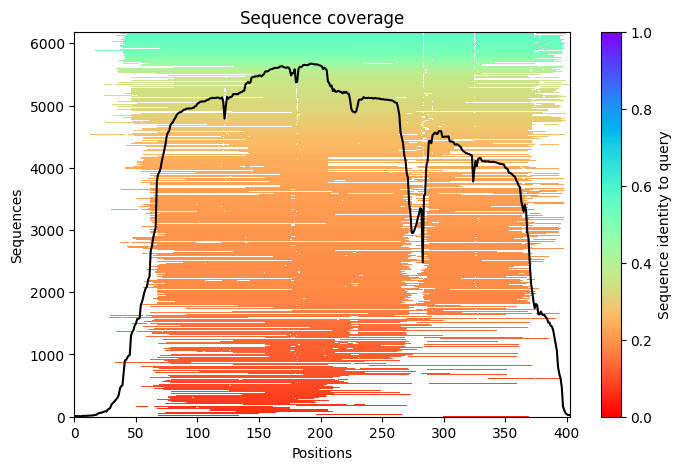

2025-07-11 18:21:07,527 Setting max_seq=512, max_extra_seq=5120
2025-07-11 18:22:29,416 alphafold2_ptm_model_1_seed_000 recycle=0 pLDDT=81.2 pTM=0.784
2025-07-11 18:22:29,464 alphafold2_ptm_model_1_seed_000 took 71.5s (0 recycles)


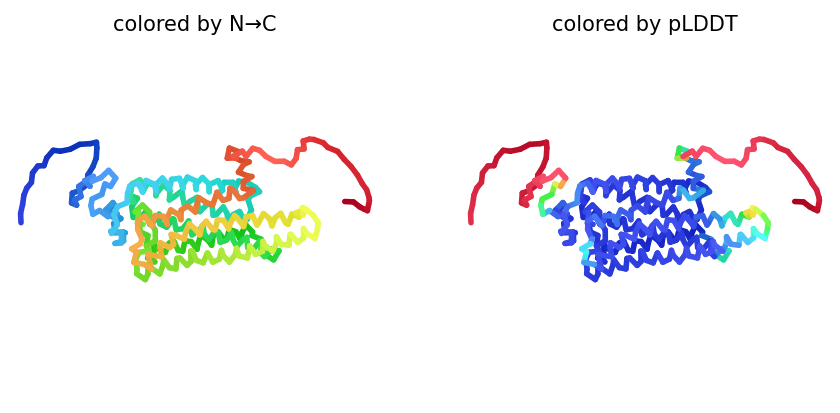

2025-07-11 18:23:10,787 alphafold2_ptm_model_2_seed_000 recycle=0 pLDDT=78.9 pTM=0.768
2025-07-11 18:23:10,809 alphafold2_ptm_model_2_seed_000 took 40.9s (0 recycles)


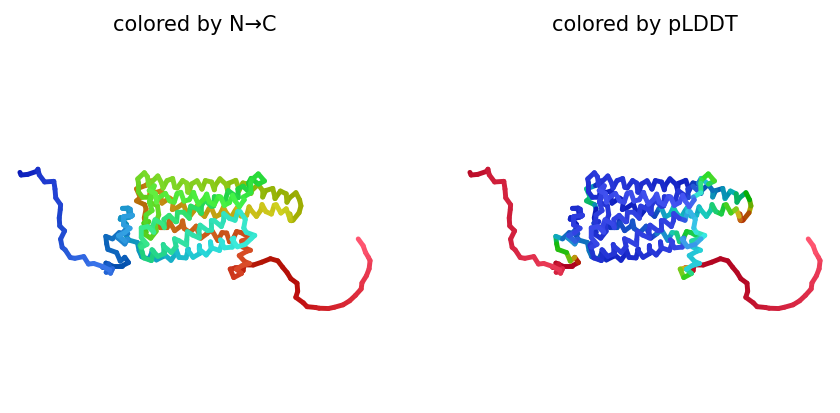

2025-07-11 18:23:54,152 alphafold2_ptm_model_3_seed_000 recycle=0 pLDDT=83.3 pTM=0.799
2025-07-11 18:23:54,211 alphafold2_ptm_model_3_seed_000 took 43.1s (0 recycles)


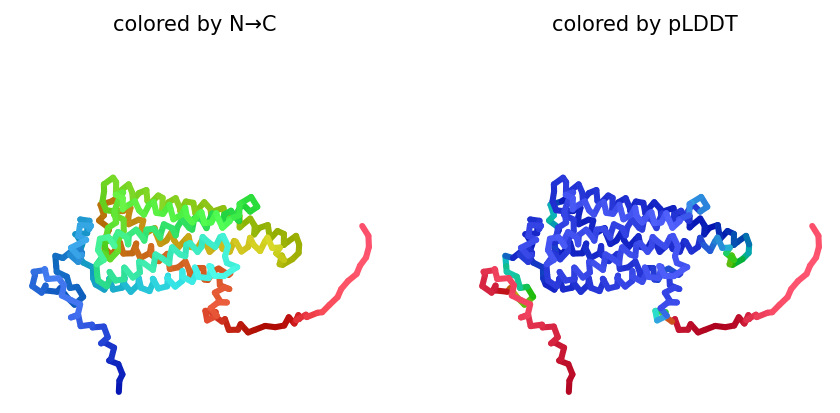

2025-07-11 18:24:36,207 alphafold2_ptm_model_4_seed_000 recycle=0 pLDDT=82.2 pTM=0.785
2025-07-11 18:24:36,230 alphafold2_ptm_model_4_seed_000 took 41.5s (0 recycles)


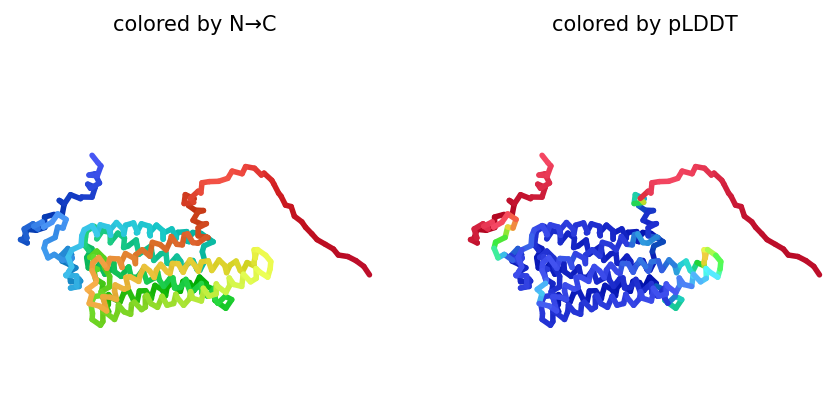

2025-07-11 18:25:18,552 alphafold2_ptm_model_5_seed_000 recycle=0 pLDDT=82.2 pTM=0.801
2025-07-11 18:25:18,613 alphafold2_ptm_model_5_seed_000 took 42.1s (0 recycles)


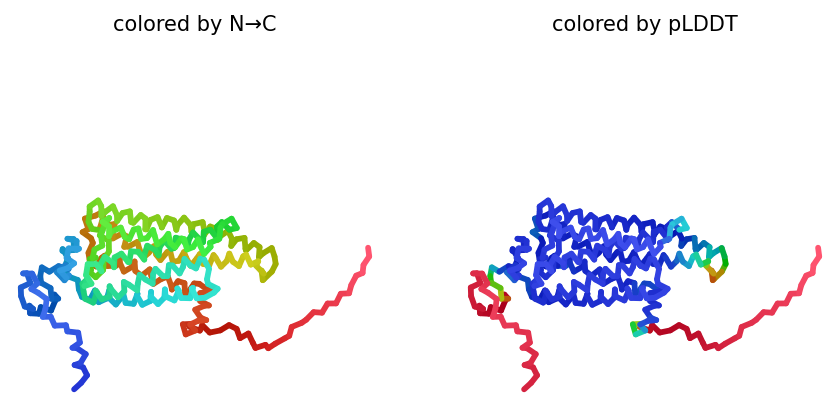

2025-07-11 18:25:19,112 reranking models by 'plddt' metric
2025-07-11 18:25:19,113 rank_001_alphafold2_ptm_model_3_seed_000 pLDDT=83.3 pTM=0.799
2025-07-11 18:25:19,114 rank_002_alphafold2_ptm_model_5_seed_000 pLDDT=82.2 pTM=0.801
2025-07-11 18:25:19,114 rank_003_alphafold2_ptm_model_4_seed_000 pLDDT=82.2 pTM=0.785
2025-07-11 18:25:19,114 rank_004_alphafold2_ptm_model_1_seed_000 pLDDT=81.2 pTM=0.784
2025-07-11 18:25:19,114 rank_005_alphafold2_ptm_model_2_seed_000 pLDDT=78.9 pTM=0.768
2025-07-11 18:25:21,096 Done


0

In [8]:
#@title 2. Alineamiento multiple (MSA) y generar predicción con la red neuronal de AlphaFold2
display_images = True #@param {type:"boolean"}

import sys
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from Bio import BiopythonDeprecationWarning
warnings.simplefilter(action='ignore', category=BiopythonDeprecationWarning)
from pathlib import Path
from colabfold.download import download_alphafold_params, default_data_dir
from colabfold.utils import setup_logging
from colabfold.batch import get_queries, run, set_model_type
from colabfold.plot import plot_msa_v2

import os
import numpy as np
try:
  K80_chk = os.popen('nvidia-smi | grep "Tesla K80" | wc -l').read()
except:
  K80_chk = "0"
  pass
if "1" in K80_chk:
  print("WARNING: found GPU Tesla K80: limited to total length < 1000")
  if "TF_FORCE_UNIFIED_MEMORY" in os.environ:
    del os.environ["TF_FORCE_UNIFIED_MEMORY"]
  if "XLA_PYTHON_CLIENT_MEM_FRACTION" in os.environ:
    del os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"]

from colabfold.colabfold import plot_protein
from pathlib import Path
import matplotlib.pyplot as plt

# For some reason we need that to get pdbfixer to import
if use_amber and f"/usr/local/lib/python{python_version}/site-packages/" not in sys.path:
    sys.path.insert(0, f"/usr/local/lib/python{python_version}/site-packages/")

def input_features_callback(input_features):
  if display_images:
    plot_msa_v2(input_features)
    plt.show()
    plt.close()

def prediction_callback(protein_obj, length,
                        prediction_result, input_features, mode):
  model_name, relaxed = mode
  if not relaxed:
    if display_images:
      fig = plot_protein(protein_obj, Ls=length, dpi=150)
      plt.show()
      plt.close()

result_dir = jobname
log_filename = os.path.join(jobname,"log.txt")
setup_logging(Path(log_filename))

queries, is_complex = get_queries(queries_path)
model_type = set_model_type(is_complex, model_type)

if "multimer" in model_type and max_msa is not None:
  use_cluster_profile = False
else:
  use_cluster_profile = True

download_alphafold_params(model_type, Path("."))
results = run(
    queries=queries,
    result_dir=result_dir,
    use_templates=use_templates,
    custom_template_path=custom_template_path,
    num_relax=num_relax,
    msa_mode=msa_mode,
    model_type=model_type,
    num_models=5,
    num_recycles=num_recycles,
    relax_max_iterations=relax_max_iterations,
    recycle_early_stop_tolerance=recycle_early_stop_tolerance,
    num_seeds=num_seeds,
    use_dropout=use_dropout,
    model_order=[1,2,3,4,5],
    is_complex=is_complex,
    data_dir=Path("."),
    keep_existing_results=False,
    rank_by="auto",
    pair_mode=pair_mode,
    pairing_strategy=pairing_strategy,
    stop_at_score=float(100),
    prediction_callback=prediction_callback,
    dpi=dpi,
    zip_results=False,
    save_all=save_all,
    max_msa=max_msa,
    use_cluster_profile=use_cluster_profile,
    input_features_callback=input_features_callback,
    save_recycles=save_recycles,
    user_agent="colabfold/google-colab-main",
    calc_extra_ptm=calc_extra_ptm,
)
results_zip = f"{jobname}.result.zip"
os.system(f"zip -r {results_zip} {jobname}")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

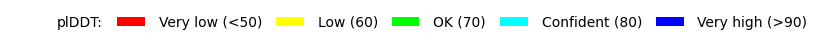

In [9]:
#@title 3. Visualización en 3D {run: "auto"}
import py3Dmol
import glob
import matplotlib.pyplot as plt
from colabfold.colabfold import plot_plddt_legend
from colabfold.colabfold import pymol_color_list, alphabet_list
rank_num = 1 #@param ["1", "2", "3", "4", "5"] {type:"raw"}
color = "lDDT" #@param ["chain", "lDDT", "rainbow"]
show_sidechains = False #@param {type:"boolean"}
show_mainchains = False #@param {type:"boolean"}

tag = results["rank"][0][rank_num - 1]
jobname_prefix = ".custom" if msa_mode == "custom" else ""
pdb_filename = f"{jobname}/{jobname}{jobname_prefix}_unrelaxed_{tag}.pdb"
pdb_file = glob.glob(pdb_filename)

def show_pdb(rank_num=1, show_sidechains=False, show_mainchains=False, color="lDDT"):
  model_name = f"rank_{rank_num}"
  view = py3Dmol.view(js='https://3dmol.org/build/3Dmol.js',)
  view.addModel(open(pdb_file[0],'r').read(),'pdb')

  if color == "lDDT":
    view.setStyle({'cartoon': {'colorscheme': {'prop':'b','gradient': 'roygb','min':50,'max':90}}})
  elif color == "rainbow":
    view.setStyle({'cartoon': {'color':'spectrum'}})
  elif color == "chain":
    chains = len(queries[0][1]) + 1 if is_complex else 1
    for n,chain,color in zip(range(chains),alphabet_list,pymol_color_list):
       view.setStyle({'chain':chain},{'cartoon': {'color':color}})

  if show_sidechains:
    BB = ['C','O','N']
    view.addStyle({'and':[{'resn':["GLY","PRO"],'invert':True},{'atom':BB,'invert':True}]},
                        {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
    view.addStyle({'and':[{'resn':"GLY"},{'atom':'CA'}]},
                        {'sphere':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
    view.addStyle({'and':[{'resn':"PRO"},{'atom':['C','O'],'invert':True}]},
                        {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
  if show_mainchains:
    BB = ['C','O','N','CA']
    view.addStyle({'atom':BB},{'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})

  view.zoomTo()
  return view

show_pdb(rank_num, show_sidechains, show_mainchains, color).show()
if color == "lDDT":
  plot_plddt_legend().show()


🔍 ¿Cómo describirías la estructura? ¿Cómo crees que se relacione con su función en las células?


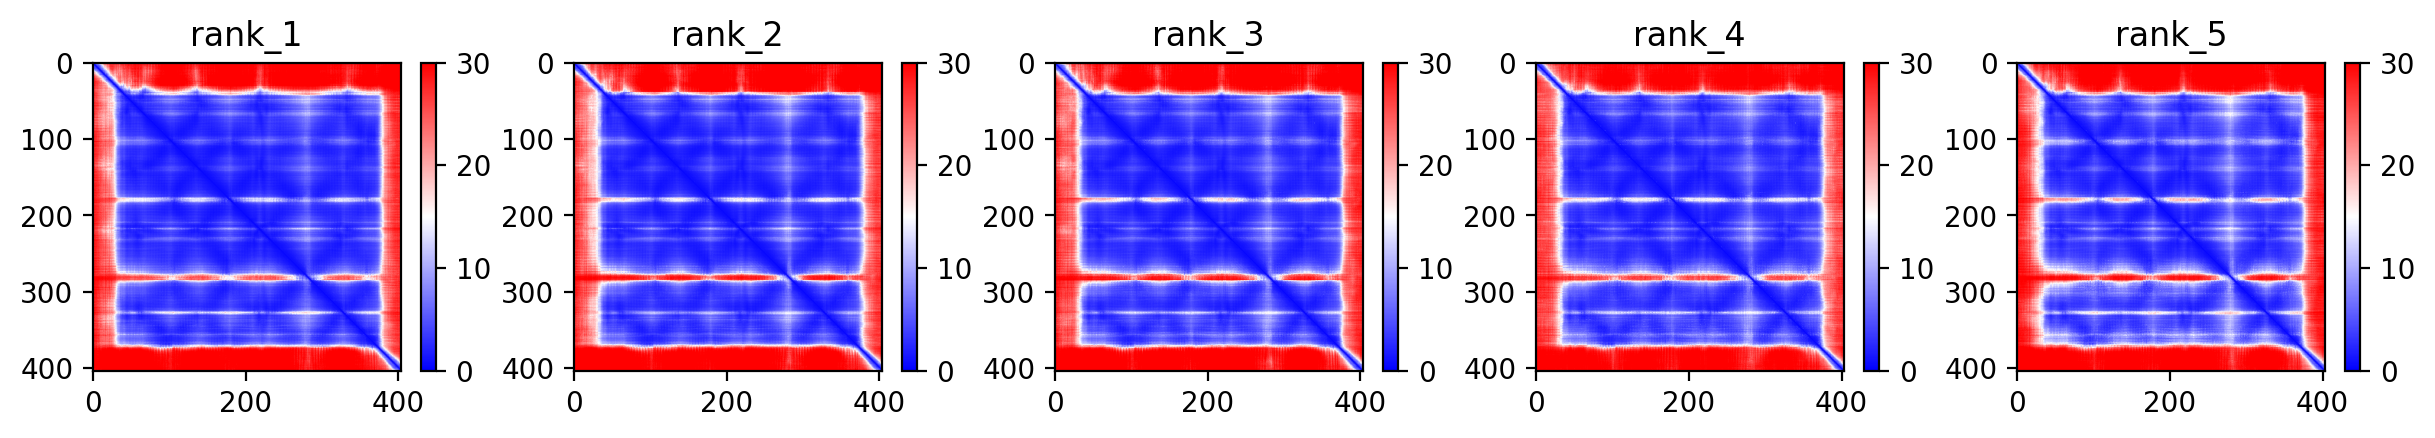
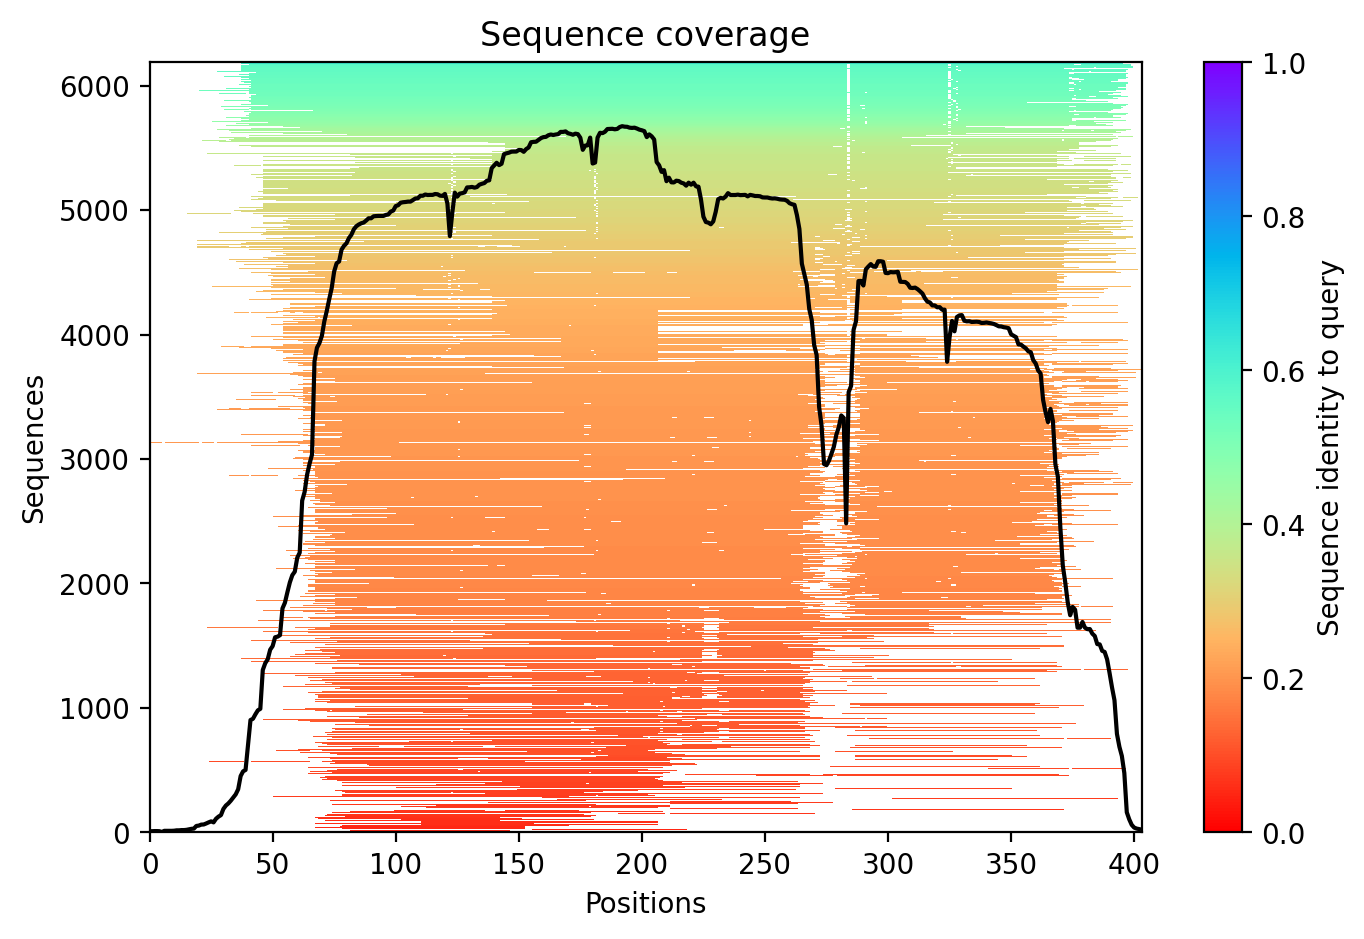
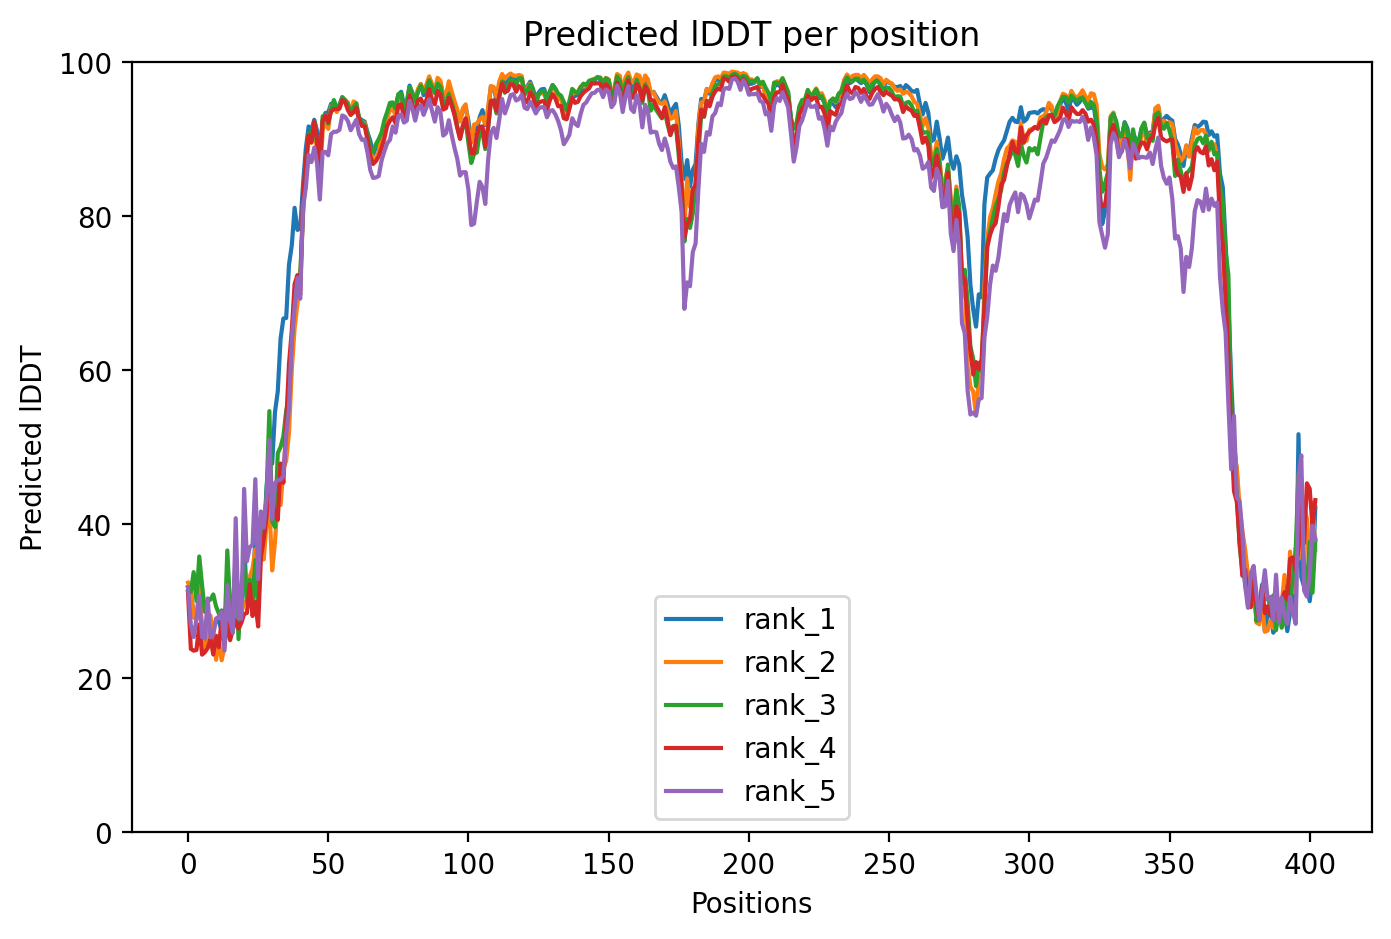

In [10]:
#@title 4. Gráficos adicionales {run: "auto"}
from IPython.display import display, HTML
import base64
from html import escape

# see: https://stackoverflow.com/a/53688522
def image_to_data_url(filename):
  ext = filename.split('.')[-1]
  prefix = f'data:image/{ext};base64,'
  with open(filename, 'rb') as f:
    img = f.read()
  return prefix + base64.b64encode(img).decode('utf-8')

pae = ""
pae_file = os.path.join(jobname,f"{jobname}{jobname_prefix}_pae.png")
if os.path.isfile(pae_file):
    pae = image_to_data_url(pae_file)
cov = image_to_data_url(os.path.join(jobname,f"{jobname}{jobname_prefix}_coverage.png"))
plddt = image_to_data_url(os.path.join(jobname,f"{jobname}{jobname_prefix}_plddt.png"))
display(HTML(f"""
<style>
  img {{
    float:left;
  }}
  .full {{
    max-width:100%;
  }}
  .half {{
    max-width:50%;
  }}
  @media (max-width:640px) {{
    .half {{
      max-width:100%;
    }}
  }}
</style>
<div style="max-width:90%; padding:2em;">
  <h1>Plots for {escape(jobname)}</h1>
  { '<!--' if pae == '' else '' }<img src="{pae}" class="full" />{ '-->' if pae == '' else '' }
  <img src="{cov}" class="half" />
  <img src="{plddt}" class="half" />
</div>
"""))

**Descripción de las gráficas**

*   Número de secuencias por posición: Queremos ver al menos 30 secuencias por posición; para obtener el mejor rendimiento, lo ideal son unas 100 secuencias.
*   plDDT predicho por posición: Confianza del modelo (sobre 100) en cada posición. Cuanto más alto, mejor.
*   Error de alineamiento predicho: Para homooligómeros, puede ser una métrica útil para evaluar la confianza del modelo en la interfaz. Cuanto más bajo, mejor.

🔍 ¿Con base en esto crees que podemos confiar en la estructura?

In [11]:
#@title     5. Descargar resultados
#@markdown Si tienes problemas para descargar el archivo de resultados, intenta desactivar tu bloqueador de anuncios y vuelve a ejecutar esta celda. Si eso no funciona, haz clic en el pequeño ícono de carpeta a la izquierda, navega hasta el archivo `jobname.result.zip`, haz clic derecho y selecciona \"Download\"
if msa_mode == "custom":
  print("Don't forget to cite your custom MSA generation method.")

files.download(f"{jobname}.result.zip")

if save_to_google_drive == True and drive:
  uploaded = drive.CreateFile({'title': f"{jobname}.result.zip"})
  uploaded.SetContentFile(f"{jobname}.result.zip")
  uploaded.Upload()
  print(f"Uploaded {jobname}.result.zip to Google Drive with ID {uploaded.get('id')}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Uploaded test_opsin_02546.result.zip to Google Drive with ID 15bD6JJasGzPghv-oG54OoaY09oSCRkwE


**Contenido del archivo ZIP de resultados**



1.   Estructuras en formato PDB ordenadas por pLDDT promedio y, en el caso de complejos, por pTMscore (en versiones sin relajar y relajadas si use_amber está habilitado).
2.   Gráficas de la calidad del modelo.
3.   Gráficas de la cobertura de la MSA.
4.   Archivo de registro de parámetros.
5.   MSA de entrada en formato A3M.
6.   Un archivo predicted_aligned_error_v1.json con el formato de AlphaFold-DB y un scores.json para cada modelo, que contiene un arreglo (lista de listas) con el PAE, una lista con el pLDDT promedio y el pTMscore.
7.   Archivo BibTeX con las citas de todas las herramientas y bases de datos utilizadas.

## 6. Alineamiento de estructuras proteicas

*   En la carpeta de resultados busca los que tengan la extension `.pdb`

*   En una nueva pestaña dirígite a https://search.foldseek.com/search


*   Da click en `UPLOAD PDB` y sube la mejor prediccion (aquella que contiene rank_001 en el nombre).
*   Da click en `SEARCH` y espera los resultados. 🚀

<br/>

🔍 **Algunas preguntas a responder:** <br/>
¿Cuáles son las proteínas más parecidas a nuestra secuencia? <br/>
¿De qué especies son? <br/>
¿Qué regiones cambian? <br/>

Presta especial atencion a los resultados en `PDB100` (corresponden a estructuras determinadas experimentalmente) y `AFDB50` (predicciones de ALphaFold de una mayor diversidad de especies). <br/> <br/>

### 🔧    **Actividad:** Repite el proceso con tu proteína favorita.
Algunos buenos candidatos podrian ser genes diferencialmente expresados en el cerebro de nuestro arácnido como *evm.model.CTG_534.30.1* o el homólogo de genes circadianos como *Timeless*.  <br/>
Estas secuencias se encuentran el archivo `candidates_AlphaFold.faa`, o puedes explorar cualquier otra secuencia de las 19 mil secuencias en su proteoma `IOZCAS_Hgram_genomeAssembly_1.0_cds_proteins.faa`.  <br/>
Ten en cuenta que por limitaciones computacionales solo podras generar predicciones para péptidos de tamaño mediano (alrededor de 500 aminoácidos). <br/> <br/>





**Referencias**

Este notebook esta basado en su mayor parte en la version en ingles disponible en: https://colab.research.google.com/github/sokrypton/ColabFold/blob/main/AlphaFold2.ipynb

<br>

**Licencia**

The source code of ColabFold is licensed under [MIT](https://raw.githubusercontent.com/sokrypton/ColabFold/main/LICENSE). Additionally, this notebook uses the AlphaFold2 source code and its parameters licensed under [Apache 2.0](https://raw.githubusercontent.com/deepmind/alphafold/main/LICENSE) and [CC BY 4.0](https://creativecommons.org/licenses/by-sa/4.0/) respectively. Read more about the AlphaFold license [here](https://github.com/deepmind/alphafold).

